# Etapa 2 — Modelagem com Redes Neurais (MLP em PyTorch)

**Grupo:** Grupo 21  
**Dataset:** IBM Telco Customer Churn (pré-processado em `01_eda_feature_engineering.ipynb`)  
**Target:** `Churn` (0 = No, 1 = Yes)

---

## Estrutura

| # | Seção | Descrição |
|---|---|---|
| 1 | Setup | Imports, seeds, constantes globais |
| 2 | Dados | Carregamento e verificações básicas |
| 3 | Split | Train / Val / Test estratificado |
| 4 | Arquitetura MLP | `nn.Module` com BatchNorm + Dropout |
| 5 | Loop de Treino | Early stopping (PR-AUC) + DataLoader |
| 6 | Ensembles | Random Forest e Gradient Boosting |
| 7 | Comparação | ≥ 4 métricas + curvas ROC / PR |
| 8 | Análise de Custo | Trade-off FP×1 vs FN×10 + threshold ótimo |
| 9 | MLflow | Registro de todos os modelos |

---
## 1. Setup

In [1]:
# ── Bibliotecas padrão ────────────────────────────────────────────────────────
import logging
import warnings
from typing import Dict, Any, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ── PyTorch — rede neural e DataLoader ───────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ── Scikit-Learn — baselines e métricas ──────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

# ── MLflow — rastreamento de experimentos ─────────────────────────────────────
import mlflow
import mlflow.sklearn
import mlflow.pytorch

# ── Configuração global ───────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')
logger = logging.getLogger(__name__)

# ── Constantes globais ────────────────────────────────────────────────────────
RANDOM_STATE  = 42
TEST_SIZE     = 0.2
VAL_SIZE      = 0.15   # fração do train usada para early stopping da MLP
BATCH_SIZE    = 256
N_EPOCHS      = 300
PATIENCE      = 20
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
COST_FP       = 1      # custo oferta de retenção desnecessária (falso positivo)
COST_FN       = 10     # custo perda do cliente — CLV (falso negativo)
TARGET_COL    = 'Churn'
PATH_DATA     = 'data/processed/churn_processed.csv'
EXPERIMENT    = 'telco_churn_models'  # experimento MLflow compartilhado por todos os modelos

# ── Seeds — reprodutibilidade ─────────────────────────────────────────────────
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ── Estilo visual ─────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (8, 4)})

logger.info('Device: %s | PyTorch: %s', device, torch.__version__)

---
## 2. Carregamento dos Dados

In [2]:
df = pd.read_csv(PATH_DATA)
df = df.drop(columns=['TotalCharges'], errors='ignore')  # correlação alta com Tenure (r=0.83)

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

logger.info('Shape: X=%s | y=%s', X.shape, y.shape)
logger.info('Distribuição target:\n%s', y.value_counts(normalize=True).round(4).to_string())
display(X.head(3))

,SeniorCitizen,Tenure,MonthlyCharges,is_monthly_contract,is_new_customer,Gender_Male,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Partner,Dependents,PhoneService,PaperlessBilling
0,-0.439916,-1.277445,-1.160323,0.904184,1.937929,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,-0.439916,0.066327,-0.259629,-1.105970,-0.516015,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-0.439916,-1.236724,-0.362660,0.904184,1.937929,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0


---
## 3. Train / Val / Test Split

O conjunto de **validação** é separado do treino para monitorar PR-AUC durante o early stopping.  
O **teste** permanece intocado até a avaliação final.

In [3]:
# Split primário: 80% treino + 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Split secundário: 85% treino efetivo + 15% validação (para early stopping da MLP)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

logger.info('Treino efetivo: %d | Val: %d | Teste: %d', len(X_tr), len(X_val), len(X_test))

# pos_weight = neg/pos — corrige desbalanceamento na BCEWithLogitsLoss
n_pos = int(y_tr.sum())
n_neg = len(y_tr) - n_pos
POS_WEIGHT = n_neg / n_pos

logger.info('pos_weight (neg/pos): %.4f  |  neg=%d  pos=%d', POS_WEIGHT, n_neg, n_pos)

---
## 4. Arquitetura MLP (PyTorch)

Rede totalmente conectada com:  
- `BatchNorm1d` após cada camada linear → estabiliza gradientes  
- `ReLU` como função de ativação  
- `Dropout` → regularização  
- Saída escalar (logit) compatível com `BCEWithLogitsLoss`

In [4]:
# ── Definição da arquitetura ──────────────────────────────────────────────────
class ChurnMLP(nn.Module):
    """MLP para classificação binária de churn.

    Blocos: Linear → BatchNorm1d → ReLU → Dropout (repetido por camada oculta).
    Saída: logit escalar — compatível com BCEWithLogitsLoss.
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dims: List[int],
        dropout_rate: float = 0.3,
    ) -> None:
        super().__init__()
        layers: List[nn.Module] = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),   # normaliza ativações entre camadas
                nn.ReLU(),           # não-linearidade
                nn.Dropout(dropout_rate),  # regularização — evita overfitting
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))  # logit de saída (sem sigmoid — usada na loss)
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(1)


# ── Instanciar modelo ─────────────────────────────────────────────────────────
INPUT_DIM    = X_tr.shape[1]   # 31 features (após remoção de TotalCharges)
HIDDEN_DIMS  = [128, 64]       # duas camadas ocultas
DROPOUT_RATE = 0.3

mlp = ChurnMLP(INPUT_DIM, HIDDEN_DIMS, DROPOUT_RATE).to(device)
n_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)

logger.info('Arquitetura MLP:\n%s', mlp)
logger.info('Parâmetros treináveis: %d', n_params)

---
## 5. Loop de Treino com Early Stopping e Batching

- **Loss:** `BCEWithLogitsLoss` com `pos_weight` (trata desbalanceamento)  
- **Otimizador:** Adam com weight decay  
- **Batching:** `DataLoader` com shuffle  
- **Early stopping:** monitora PR-AUC na validação; restaura melhor estado ao final

In [5]:
def train_mlp(
    model: nn.Module,
    X_tr_np: np.ndarray,
    y_tr_np: np.ndarray,
    X_val_np: np.ndarray,
    y_val_np: np.ndarray,
    pos_weight: float,
    n_epochs: int = N_EPOCHS,
    batch_size: int = BATCH_SIZE,
    lr: float = LR,
    patience: int = PATIENCE,
    weight_decay: float = WEIGHT_DECAY,
) -> Tuple[nn.Module, List[Dict]]:
    X_tr_t  = torch.FloatTensor(X_tr_np).to(device)
    y_tr_t  = torch.FloatTensor(y_tr_np).to(device)
    X_val_t = torch.FloatTensor(X_val_np).to(device)
    y_val_t = torch.FloatTensor(y_val_np).to(device)

    loader = DataLoader(
        TensorDataset(X_tr_t, y_tr_t),
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(RANDOM_STATE),
    )

    pw        = torch.tensor([pos_weight], dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_pr_auc   = -np.inf
    best_state: Dict = {}
    patience_cnt  = 0
    history: List[Dict] = []

    for epoch in range(1, n_epochs + 1):
        # ── treino ────────────────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0
        for Xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(yb)
        train_loss = epoch_loss / len(X_tr_np)

        # ── validação ─────────────────────────────────────────────────────────
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_loss   = criterion(val_logits, y_val_t).item()
            val_probs  = torch.sigmoid(val_logits).cpu().numpy()

        val_pr_auc = average_precision_score(y_val_np, val_probs)
        history.append({'epoch': epoch, 'train_loss': train_loss,
                         'val_loss': val_loss, 'val_pr_auc': val_pr_auc})

        if val_pr_auc > best_pr_auc:
            best_pr_auc = val_pr_auc
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1

        if epoch % 20 == 0:
            logger.info(
                'Epoch %3d | train_loss=%.4f | val_loss=%.4f | val_PR-AUC=%.4f | patience=%d/%d',
                epoch, train_loss, val_loss, val_pr_auc, patience_cnt, patience,
            )

        if patience_cnt >= patience:
            logger.info('Early stopping epoch %d — best val_PR-AUC=%.4f', epoch, best_pr_auc)
            break

    model.load_state_dict(best_state)
    return model, history

In [6]:
mlp, history = train_mlp(
    model     = mlp,
    X_tr_np   = X_tr.values,
    y_tr_np   = y_tr.values.astype(np.float32),
    X_val_np  = X_val.values,
    y_val_np  = y_val.values.astype(np.float32),
    pos_weight= POS_WEIGHT,
)

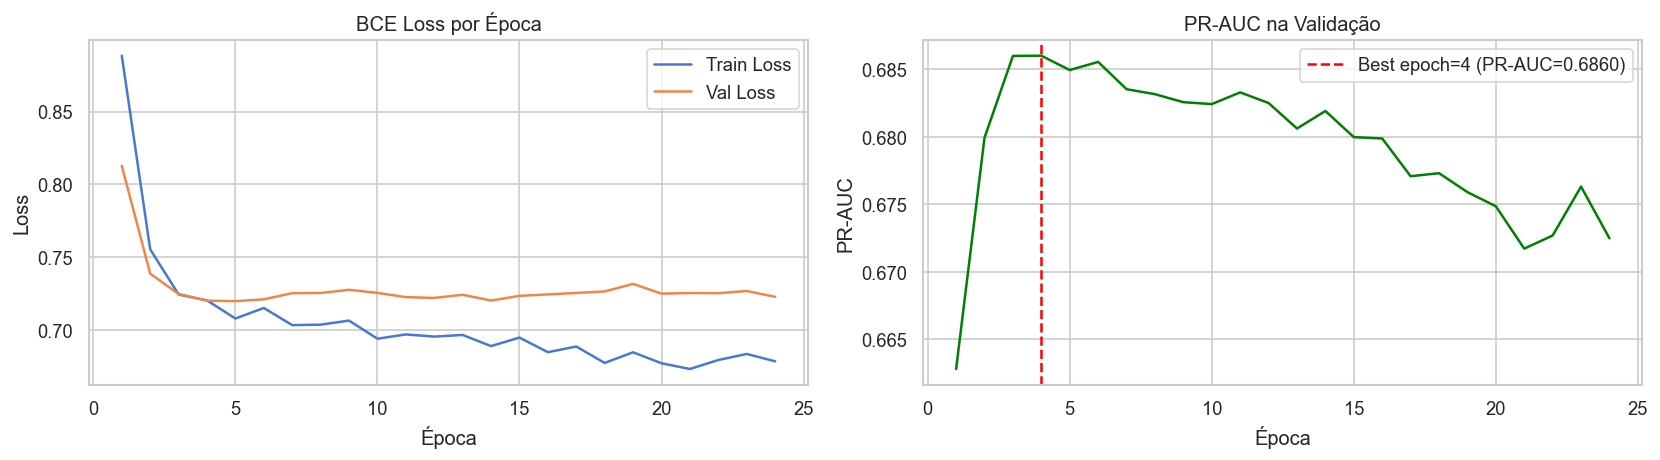

In [7]:
hist_df   = pd.DataFrame(history)
best_ep   = hist_df.loc[hist_df['val_pr_auc'].idxmax()]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='Train Loss')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   label='Val Loss')
axes[0].set_title('BCE Loss por Época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(hist_df['epoch'], hist_df['val_pr_auc'], color='green')
axes[1].axvline(x=best_ep['epoch'], color='red', linestyle='--',
                label=f"Best epoch={int(best_ep['epoch'])} (PR-AUC={best_ep['val_pr_auc']:.4f})")
axes[1].set_title('PR-AUC na Validação')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('PR-AUC')
axes[1].legend()

plt.tight_layout()
plt.show()
logger.info('Melhor epoch: %d | Val PR-AUC: %.4f', int(best_ep['epoch']), best_ep['val_pr_auc'])

---
## 6. Modelos Ensemble (árvores)

De acordo com o requisito do trabalho, é necessário comparar MLP com **modelos lineares e de árvore**.  
Treinamos aqui **Random Forest** e **Gradient Boosting**, além da regressão logística como baseline linear.

In [8]:
# Regressão Logística (baseline linear — igual ao notebook 02)
lr_model = LogisticRegression(
    solver='liblinear', random_state=RANDOM_STATE, max_iter=1000
)
lr_model.fit(X_train, y_train)
logger.info('LogisticRegression treinado.')

In [9]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
logger.info('RandomForest treinado.')

In [10]:
# Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    random_state=RANDOM_STATE,
)
gb_model.fit(X_train, y_train)
logger.info('GradientBoosting treinado.')

---
## 7. Comparação de Modelos (≥ 4 métricas)

Métricas avaliadas no conjunto de **teste** (hold-out 20%):  
`ROC-AUC` · `PR-AUC` · `F1` · `Precision` · `Recall`

In [11]:
def compute_metrics(
    name: str,
    y_true: np.ndarray,
    y_scores: np.ndarray,
    threshold: float = 0.5,
) -> Dict[str, Any]:
    y_pred = (y_scores >= threshold).astype(int)
    return {
        'model':     name,
        'roc_auc':   round(roc_auc_score(y_true, y_scores), 4),
        'pr_auc':    round(average_precision_score(y_true, y_scores), 4),
        'f1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
    }


def mlp_predict_proba(model: nn.Module, X_np: np.ndarray) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        logits = model(torch.FloatTensor(X_np).to(device))
        return torch.sigmoid(logits).cpu().numpy()


# ── Scores no conjunto de teste ───────────────────────────────────────────────
y_true       = y_test.values
lr_scores    = lr_model.predict_proba(X_test)[:, 1]
rf_scores    = rf_model.predict_proba(X_test)[:, 1]
gb_scores    = gb_model.predict_proba(X_test)[:, 1]
mlp_scores   = mlp_predict_proba(mlp, X_test.values)

# ── Métricas ──────────────────────────────────────────────────────────────────
all_metrics = [
    compute_metrics('LogisticRegression', y_true, lr_scores),
    compute_metrics('RandomForest',       y_true, rf_scores),
    compute_metrics('GradientBoosting',   y_true, gb_scores),
    compute_metrics('MLP_PyTorch',        y_true, mlp_scores),
]

comparison_df = (
    pd.DataFrame(all_metrics)
    .set_index('model')
    .sort_values('pr_auc', ascending=False)
)
display(comparison_df)

,roc_auc,pr_auc,f1,precision,recall
model,,,,,
LogisticRegression,0.8460,0.6524,0.5952,0.6711,0.5348
MLP_PyTorch,0.8435,0.6489,0.6201,0.4992,0.8182
GradientBoosting,0.8353,0.6276,0.5706,0.6421,0.5134
RandomForest,0.8250,0.6159,0.5506,0.6208,0.4947


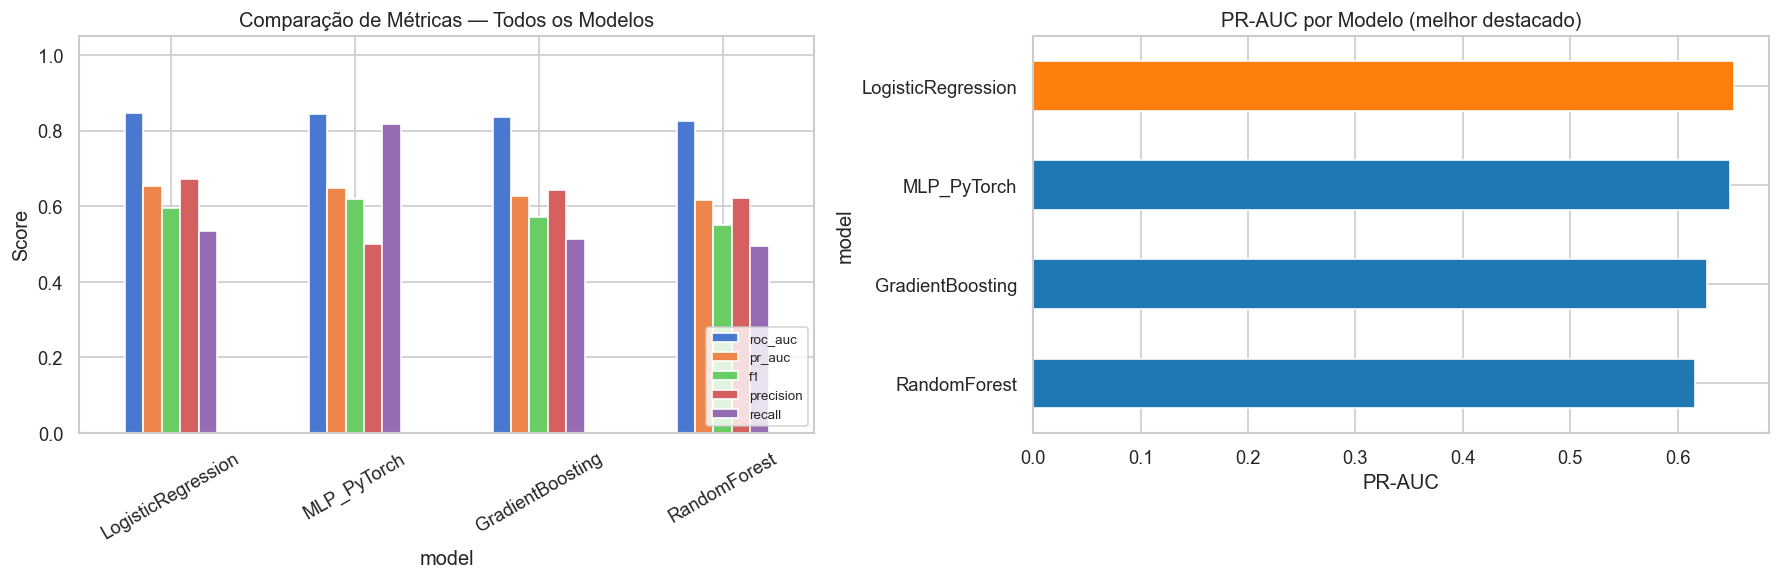

In [12]:
# ── Gráfico comparativo ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

comparison_df[['roc_auc', 'pr_auc', 'f1', 'precision', 'recall']].plot(
    kind='bar', ax=axes[0], rot=30
)
axes[0].set_title('Comparação de Métricas — Todos os Modelos')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right', fontsize=8)

best_model = comparison_df['pr_auc'].idxmax()
colors = ['#ff7f0e' if m == best_model else '#1f77b4'
          for m in comparison_df['pr_auc'].sort_values().index]
comparison_df['pr_auc'].sort_values().plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('PR-AUC por Modelo (melhor destacado)')
axes[1].set_xlabel('PR-AUC')

plt.tight_layout()
plt.show()

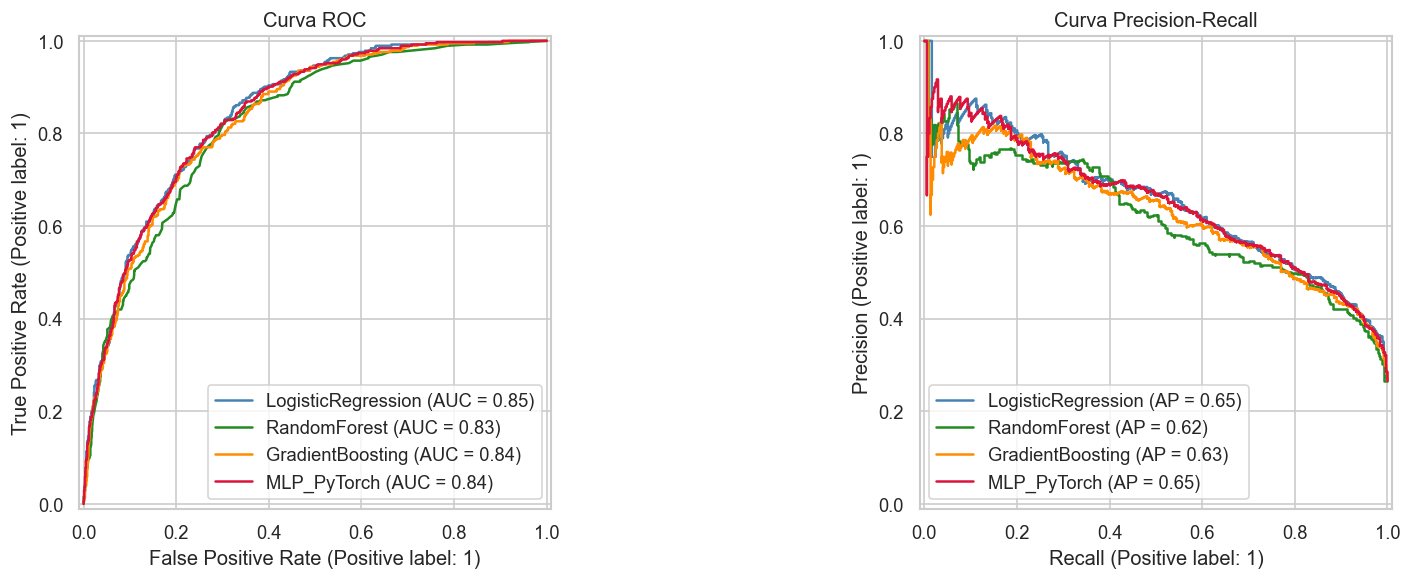

In [13]:
# ── Curvas ROC e Precision-Recall ─────────────────────────────────────────────
scores_map = {
    'LogisticRegression': lr_scores,
    'RandomForest':       rf_scores,
    'GradientBoosting':   gb_scores,
    'MLP_PyTorch':        mlp_scores,
}
colors_map = ['steelblue', 'forestgreen', 'darkorange', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for (name, sc), col in zip(scores_map.items(), colors_map):
    RocCurveDisplay.from_predictions(y_true, sc, name=name, ax=axes[0], color=col)
axes[0].set_title('Curva ROC')

for (name, sc), col in zip(scores_map.items(), colors_map):
    PrecisionRecallDisplay.from_predictions(y_true, sc, name=name, ax=axes[1], color=col)
axes[1].set_title('Curva Precision-Recall')

plt.tight_layout()
plt.show()

---
## 8. Análise de Custo — Trade-off FP × FN

No contexto de negócio de telecomunicações:

| Erro | Consequência | Custo |
|------|-------------|-------|
| Falso Positivo (FP) | Oferta de retenção desnecessária | **1** |
| Falso Negativo (FN) | Perda do cliente (CLV) | **10** |

**Custo Total = FP × 1 + FN × 10**

Varremos os thresholds para encontrar o ponto de mínimo custo para cada modelo.

In [14]:
def scan_threshold_cost(
    y_true: np.ndarray,
    scores: np.ndarray,
    cost_fp: int = COST_FP,
    cost_fn: int = COST_FN,
    n_steps: int = 500,
) -> pd.DataFrame:
    thresholds = np.linspace(0.01, 0.99, n_steps)
    rows = []
    for t in thresholds:
        pred = (scores >= t).astype(int)
        fp = int(((y_true == 0) & (pred == 1)).sum())
        fn = int(((y_true == 1) & (pred == 0)).sum())
        rows.append({'threshold': t, 'fp': fp, 'fn': fn,
                      'cost': fp * cost_fp + fn * cost_fn})
    return pd.DataFrame(rows)


mlp_cost_df   = scan_threshold_cost(y_true, mlp_scores)
best_mlp_row  = mlp_cost_df.loc[mlp_cost_df['cost'].idxmin()]
opt_thr_mlp   = float(best_mlp_row['threshold'])
min_cost_mlp  = float(best_mlp_row['cost'])

# Custo com threshold padrão 0.5
pred_default  = (mlp_scores >= 0.5).astype(int)
fp_d = int(((y_true == 0) & (pred_default == 1)).sum())
fn_d = int(((y_true == 1) & (pred_default == 0)).sum())
default_cost  = fp_d * COST_FP + fn_d * COST_FN

logger.info('MLP — threshold=0.50: custo=%d (FP=%d, FN=%d)', default_cost, fp_d, fn_d)
logger.info('MLP — threshold=%.4f: custo=%d (FP=%d, FN=%d) | redução=%.1f%%',
            opt_thr_mlp, int(min_cost_mlp),
            int(best_mlp_row['fp']), int(best_mlp_row['fn']),
            (default_cost - min_cost_mlp) / default_cost * 100)

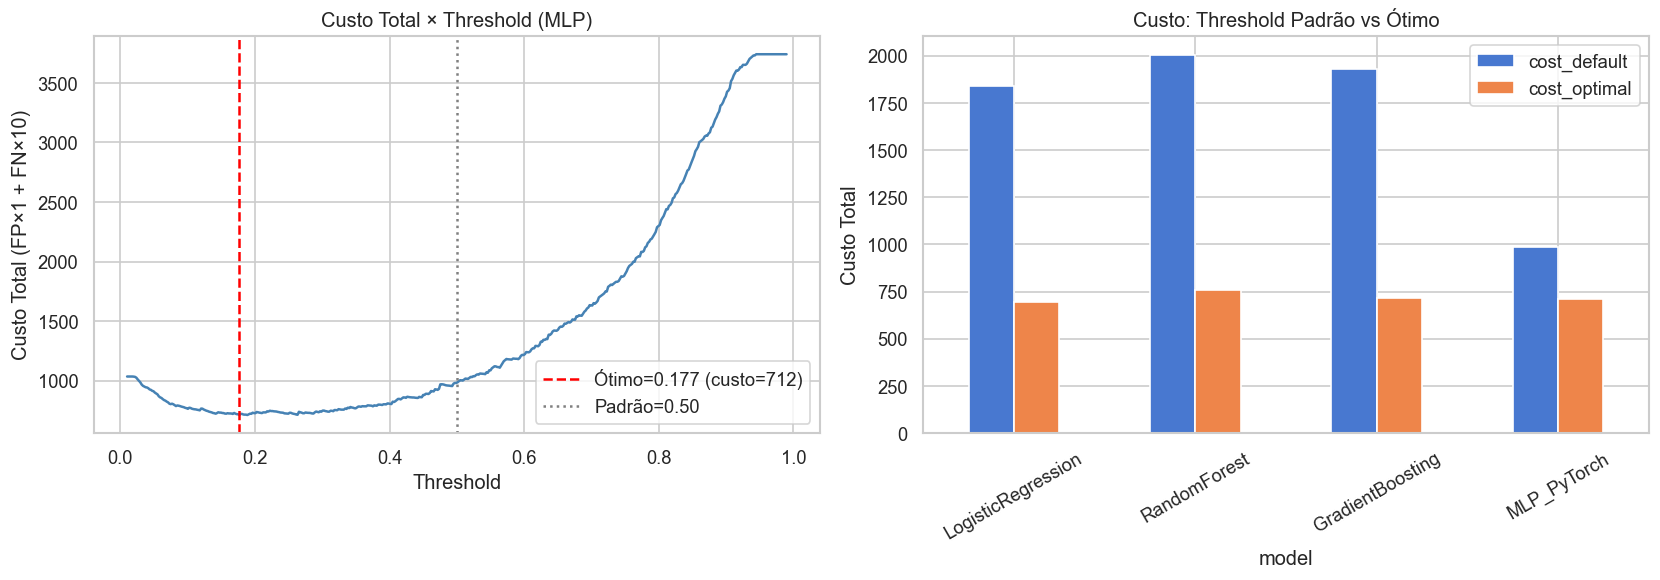

,cost_default,cost_optimal,optimal_threshold
model,,,
LogisticRegression,1838,692,0.0866
RandomForest,2003,756,0.0768
GradientBoosting,1927,714,0.0552
MLP_PyTorch,987,712,0.1769


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Custo × threshold (MLP)
axes[0].plot(mlp_cost_df['threshold'], mlp_cost_df['cost'], color='steelblue')
axes[0].axvline(x=opt_thr_mlp, color='red', linestyle='--',
                label=f'Ótimo={opt_thr_mlp:.3f} (custo={int(min_cost_mlp)})')
axes[0].axvline(x=0.5, color='gray', linestyle=':', label='Padrão=0.50')
axes[0].set_title('Custo Total × Threshold (MLP)')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel(f'Custo Total (FP×{COST_FP} + FN×{COST_FN})')
axes[0].legend()

# Comparação de custo mínimo entre todos os modelos
cost_summary = []
for name, sc in scores_map.items():
    cdf  = scan_threshold_cost(y_true, sc)
    best = cdf.loc[cdf['cost'].idxmin()]
    pred_d = (sc >= 0.5).astype(int)
    fp_d2 = int(((y_true == 0) & (pred_d == 1)).sum())
    fn_d2 = int(((y_true == 1) & (pred_d == 0)).sum())
    cost_summary.append({
        'model':             name,
        'cost_default':      fp_d2 * COST_FP + fn_d2 * COST_FN,
        'cost_optimal':      int(best['cost']),
        'optimal_threshold': round(float(best['threshold']), 4),
    })

cost_cmp_df = pd.DataFrame(cost_summary).set_index('model')

cost_cmp_df[['cost_default', 'cost_optimal']].plot(kind='bar', ax=axes[1], rot=30)
axes[1].set_title('Custo: Threshold Padrão vs Ótimo')
axes[1].set_ylabel('Custo Total')
axes[1].legend()

plt.tight_layout()
plt.show()

display(cost_cmp_df)

---
## 9. Registro em MLflow

Todos os modelos (LogisticRegression retroativo + Random Forest + Gradient Boosting + MLP) são  
registrados no mesmo experimento **`telco_churn_models`** para comparação centralizada.

In [16]:
mlflow.set_experiment(EXPERIMENT)

def _log_sklearn(
    run_name: str,
    model_obj,
    params: Dict,
    metrics: Dict,
) -> None:
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        for k, v in metrics.items():
            if k != 'model':
                mlflow.log_metric(k, float(v))
        mlflow.sklearn.log_model(model_obj, artifact_path='model')
    logger.info('MLflow: %s registrado.', run_name)


# ── Logistic Regression (baseline retroativo) ─────────────────────────────────
_log_sklearn(
    run_name  = 'log_reg_baseline',
    model_obj = lr_model,
    params    = {'model': 'LogisticRegression', 'solver': 'liblinear',
                  'C': 1.0, 'test_size': TEST_SIZE},
    metrics   = compute_metrics('LogisticRegression', y_true, lr_scores),
)

# ── Random Forest ─────────────────────────────────────────────────────────────
_log_sklearn(
    run_name  = 'random_forest',
    model_obj = rf_model,
    params    = {'model': 'RandomForest', 'n_estimators': 200,
                  'class_weight': 'balanced', 'test_size': TEST_SIZE},
    metrics   = compute_metrics('RandomForest', y_true, rf_scores),
)

# ── Gradient Boosting ─────────────────────────────────────────────────────────
_log_sklearn(
    run_name  = 'gradient_boosting',
    model_obj = gb_model,
    params    = {'model': 'GradientBoosting', 'n_estimators': 200,
                  'learning_rate': 0.1, 'max_depth': 4,
                  'subsample': 0.8, 'test_size': TEST_SIZE},
    metrics   = compute_metrics('GradientBoosting', y_true, gb_scores),
)

2026/04/16 21:38:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 21:38:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


PermissionError: [WinError 5] Acesso negado: 'C:\\Users\\vkenj'

In [ ]:
# ── MLP PyTorch ───────────────────────────────────────────────────────────────
import tempfile, os

mlp_metrics_final = compute_metrics('MLP_PyTorch', y_true, mlp_scores)

with mlflow.start_run(run_name='mlp_pytorch'):
    mlflow.log_params({
        'model':          'MLP_PyTorch',
        'input_dim':      INPUT_DIM,
        'hidden_dims':    str(HIDDEN_DIMS),
        'dropout_rate':   DROPOUT_RATE,
        'batch_size':     BATCH_SIZE,
        'lr':             LR,
        'weight_decay':   WEIGHT_DECAY,
        'patience':       PATIENCE,
        'pos_weight':     round(POS_WEIGHT, 4),
        'n_epochs_trained': len(history),
        'test_size':      TEST_SIZE,
        'val_size':       VAL_SIZE,
    })

    # métricas padrão (threshold=0.5)
    for k, v in mlp_metrics_final.items():
        if k != 'model':
            mlflow.log_metric(k, float(v))

    # métricas de custo
    mlflow.log_metric('optimal_threshold_cost', round(opt_thr_mlp, 4))
    mlflow.log_metric('min_cost',      min_cost_mlp)
    mlflow.log_metric('default_cost',  default_cost)
    mlflow.log_metric('cost_reduction_pct',
                       round((default_cost - min_cost_mlp) / default_cost * 100, 2))

    # curva de treino como artefato CSV
    hist_path = os.path.join(tempfile.gettempdir(), 'mlp_training_history.csv')
    hist_df.to_csv(hist_path, index=False)
    mlflow.log_artifact(hist_path, artifact_path='metrics')

    # modelo PyTorch
    mlflow.pytorch.log_model(mlp, artifact_path='model')

logger.info('MLflow: MLP PyTorch registrado no experimento "%s".', EXPERIMENT)

---
## Resumo Final

Execute a célula abaixo para ver a tabela comparativa consolidada e as principais conclusões.

In [ ]:
# ── Resumo consolidado ────────────────────────────────────────────────────────
logger.info('=' * 60)
logger.info('COMPARAÇÃO FINAL — MÉTRICAS NO CONJUNTO DE TESTE')
logger.info('=' * 60)
display(comparison_df)

logger.info('=' * 60)
logger.info('ANÁLISE DE CUSTO (FP=%d, FN=%d)', COST_FP, COST_FN)
logger.info('=' * 60)
display(cost_cmp_df)

best_pr   = comparison_df['pr_auc'].idxmax()
best_cost = cost_cmp_df['cost_optimal'].idxmin()

logger.info('Melhor PR-AUC:     %s (%.4f)', best_pr,   comparison_df.loc[best_pr, 'pr_auc'])
logger.info('Menor custo ótimo: %s (%d)',   best_cost, cost_cmp_df.loc[best_cost, 'cost_optimal'])